In [4]:
import pandas as pd

# Load the new file with the target column
df = pd.read_csv('readings_with_test_labels.csv')

# Define your features based on the column names in your CSV
features = ['temp_C', 'rh_pct', 'voc', 'nh3', 'hcho']

# Now you can proceed with the Scaling, Windowing, and Model Training steps
print(df.head())

                 wall_time  millis_ms  temp_C  rh_pct mode    voc    nh3  \
0  2026-03-04T11:51:20.440     965195    23.5    22.4    V  1.366  0.562   
1  2026-03-04T11:51:21.450     966205    23.5    22.4    V  1.365  0.563   
2  2026-03-04T11:51:22.460     967215    23.5    22.3    V  1.366  0.563   
3  2026-03-04T11:51:23.469     968225    23.5    22.3    V  1.362  0.562   
4  2026-03-04T11:51:24.480     969235    23.5    22.3    V  1.363  0.563   

    hcho  target  
0  0.394       0  
1  0.394       0  
2  0.396       0  
3  0.394       0  
4  0.395       0  


### SVM and KNN

KNN Accuracy: 1.00
SVM Accuracy: 0.98

==================== KNN DETAILED REPORT ====================
              precision    recall  f1-score   support

       Sweat       1.00      1.00      1.00        31
       Blood       1.00      1.00      1.00        32

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63



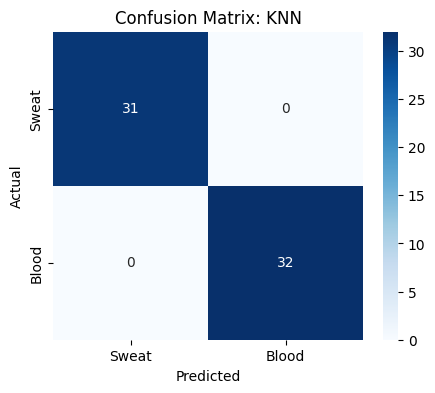


==================== SVM DETAILED REPORT ====================
              precision    recall  f1-score   support

       Sweat       1.00      0.97      0.98        31
       Blood       0.97      1.00      0.98        32

    accuracy                           0.98        63
   macro avg       0.98      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63



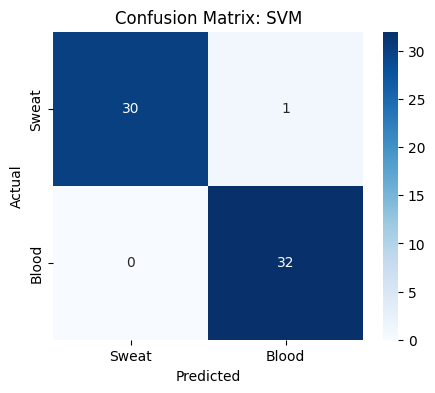

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. LOAD DATA
# Using the test file with the added target column
df = pd.read_csv('readings_with_test_labels.csv')

# Define features based on your specific sensor network
features = ['temp_C', 'rh_pct', 'voc', 'nh3', 'hcho']

# 2. PREPROCESS: Scaling
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# 3. WINDOWING FUNCTION
def create_dataset(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        window = data.iloc[i:(i + window_size)][features].values
        label = data.iloc[i + window_size]['target']
        X.append(window)
        y.append(label)
    return np.array(X), np.array(y)

window_size = 10
X_raw, y = create_dataset(df, window_size)

# --- PART 1: KNN & SVM ---
X_flattened = X_raw.reshape(X_raw.shape[0], -1)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_y_pred = knn.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_y_pred):.2f}")

# SVM Classifier
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)
svm_y_pred = svm.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_y_pred):.2f}")

# ========================================================
# --- ADDED: RESULTS & EVALUATION ---
# ========================================================

def plot_and_report(y_true, y_pred, model_name):
    print(f"\n{'='*20} {model_name} DETAILED REPORT {'='*20}")
    print(classification_report(y_true, y_pred, target_names=['Sweat', 'Blood']))

    # Generate Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sweat', 'Blood'], yticklabels=['Sweat', 'Blood'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run for both models
plot_and_report(y_test, knn_y_pred, "KNN")
plot_and_report(y_test, svm_y_pred, "SVM")

### LSTM (Still need work)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# LSTM expects 3D input: (Samples, Time_Steps, Features)
# We use the X_raw from above which is already (N, 10, 5)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_raw, y, test_size=0.2)

model = Sequential([
    # Input shape is (window_size, number_of_sensors)
    LSTM(64, input_shape=(window_size, len(features)), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Binary: Blood (1) vs Sweat (0)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, validation_split=0.1)

# Evaluate
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm)
print(f"LSTM Accuracy: {accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6290 - loss: 0.6250 - val_accuracy: 1.0000 - val_loss: 0.4319
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9572 - loss: 0.4704 - val_accuracy: 1.0000 - val_loss: 0.2804
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9513 - loss: 0.3182 - val_accuracy: 1.0000 - val_loss: 0.1304
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9755 - loss: 0.1513 - val_accuracy: 1.0000 - val_loss: 0.0416
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9366 - loss: 0.1114 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9808 - loss: 0.0535 - val_accuracy: 1.0000 - val_loss: 0.0236
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9741 - loss: 0.0573 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9917 - loss: 0.0315 - val_accuracy: 1.0000 - v